## TRATAMENTO DA BASE DE DADOS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('vendas_aguas_LGPD.csv', delimiter=';')
df.head(10)

,data_pedido_entrega,semana,qnt_aguas_entregues,qnt_aguas_tickets,Obs,id_cliente
0,2023-01-02 00:00:00,Segunda,1.0,03/03,NaN,89
1,2023-01-02 00:00:00,Segunda,1.0,NaN,NaN,102
2,2023-01-02 00:00:00,Segunda,2.0,NaN,NaN,120
3,2023-01-02 00:00:00,Segunda,2.0,NaN,NaN,50
4,2023-01-02 00:00:00,Segunda,1.0,07/10,NaN,8
5,2023-01-02 00:00:00,Segunda,1.0,NaN,NaN,44
6,2023-01-04 00:00:00,Quarta,1.0,10/10,NaN,4
7,2023-01-04 00:00:00,Quarta,2.0,NaN,NaN,98
8,2023-01-04 00:00:00,Quarta,2.0,NaN,NaN,97
9,2023-01-05 00:00:00,Quinta,4.0,11/15,NaN,10


#### O que realizar na base:
- **Verificar os tipos de dados das colunas (data, str, int, ...), se precisar, formatar para o padrão certo;**
- Criar uma coluna somente com os anos (yyyy);
- Criar uma coluna somente com os meses (mm);
- Buscar identificar quais são os meses de cada estação e criar uma coluna com eles; 
- Desenvolver colunas como dias desde a última compra, a frequência de compra, o intervalo médio entre pedidos, a média de águas adquiridas por clientes, o total de pedidos realizados e a informação sobre a próxima compra;
- **Verificar valores ausentes e nulos e tráta-los;** <--------
- Padronizar o nome das colunas e a númeração do ID, colocar 4 digitos como padrão.

### 1 - ETAPA: Tipos de dados

In [3]:
# Conferindo os tipos de dados das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3137 entries, 0 to 3136
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   data_pedido_entrega  3137 non-null   object 
 1   semana               3137 non-null   object 
 2   qnt_aguas_entregues  3133 non-null   float64
 3   qnt_aguas_tickets    561 non-null    object 
 4   Obs                  24 non-null     object 
 5   id_cliente           3137 non-null   int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 147.2+ KB


**MODIFICAÇÃO DOS TIPO DE DADOS DAS COLUNAS**
- data_pedido_entrega = data
- qnt_aguas_entregues = int

In [4]:
# Foi notado um erro em um ano na execução do código para converter a data, onde consta 0203-07-12, 
# ao análisar a base de dados é possível constatar que os dias, meses e anos seguem sequência, então conclui-se que o ano correto é 2023,
# optei por realizar a correção do valor para não ocorrer mais erros e não acarretar em perda dados
df['data_pedido_entrega'] = df['data_pedido_entrega'].astype(str).str.replace('0203-07-12', '2023-07-12')

# Modificação dos tipos de dados
df['data_pedido_entrega'] = pd.to_datetime(df['data_pedido_entrega'], format='mixed', dayfirst=True, errors='coerce')
df['qnt_aguas_entregues'] = df['qnt_aguas_entregues'].fillna(0).astype(int)

In [5]:
# Conferindo os tipos de dados das colunas após alteração
df.dtypes

data_pedido_entrega    datetime64[ns]
semana                         object
qnt_aguas_entregues             int64
qnt_aguas_tickets              object
Obs                            object
id_cliente                      int64
dtype: object

### 2 - ETAPA: Criar novas colunas para Insights e ML

In [6]:
# Coluna somente com os anos
df['ano'] = df['data_pedido_entrega'].dt.year

# Coluna somente com os meses
df['mes'] = df['data_pedido_entrega'].dt.month

Levando em consideração que a base de dados se refere a um depósito de água localizado na região Nordeste do Brasil, é importante considerar as características climáticas locais. Conforme menciona o Google, **"Embora as datas astronômicas sejam iguais para todo o Brasil, o Nordeste vivencia o clima de forma distinta, com clima quente predominando a maior parte do ano."**

Dessa forma, para tornar a análise mais aderente à realidade da região, as estações do ano foram definidas com base no regime climático local. Assim, o período de maior ocorrência de chuvas, geralmente entre os meses de **abril e agosto**, será classificado como **Inverno**, enquanto os demais meses, caracterizados por condições predominantemente secas e ensolaradas, serão classificados como **Verão**. Essa adaptação busca representar de forma mais fiel as variações climáticas que podem influenciar o comportamento dos dados analisados.

In [7]:
# Coluna das estações
def mapear_estacao(mes):
    if mes in [4, 5, 6, 7, 8]:
        return 'Inverno'
    else:
        return 'Verão'

df['estacao'] = df['mes'].apply(mapear_estacao)

In [8]:
# Coluna com os dias dês de o último pedido/compra
df['dias_desde_utlima_compra']= (
    df.groupby('id_cliente')['data_pedido_entrega']
    .diff()
    .dt.days
)

In [9]:
# Coluna de intervalo médio entre pedido/compra por cliente
df['intervalo_medio'] = (
    df.groupby('id_cliente')['dias_desde_utlima_compra']
    .transform('mean')
)

In [10]:
# Coluna de frêquencia de pedido/compra por cliente
df['frequencia_compra'] = (
    df.groupby('id_cliente')
    .cumcount() + 1
)

In [11]:
# Coluna constando a quantidade média de águas por cliente
df['media_aguas_cliente'] = (
    df.groupby('id_cliente')['qnt_aguas_entregues']
    .transform('mean')
)

In [12]:
# Coluna de total de pedidos por cliente
df['total_pedidos'] = (
    df.groupby('id_cliente')
    .cumcount() + 1
)

In [13]:
# Colunas de probabilidade de compra futura
df['proxima_compra'] = (
    df.groupby('id_cliente')['data_pedido_entrega']
    .shift(-1)
)

df['dias_ate_proxima_compra'] = (
    df['proxima_compra'] - df['data_pedido_entrega']
).dt.days

df['vai_comprar_15dias'] = np.where(
    df['dias_ate_proxima_compra'] <= 15,
    1, 
    0
)

In [14]:
# Exibição do DataFrame com as novas colunas
df

,data_pedido_entrega,semana,qnt_aguas_entregues,qnt_aguas_tickets,Obs,id_cliente,ano,mes,estacao,dias_desde_utlima_compra,intervalo_medio,frequencia_compra,media_aguas_cliente,total_pedidos,proxima_compra,dias_ate_proxima_compra,vai_comprar_15dias
0,2023-01-02,Segunda,1,03/03,NaN,89,2023.0,1.0,Verão,NaN,5.907143,1,1.014184,1,2023-01-11,9.0,1
1,2023-01-02,Segunda,1,NaN,NaN,102,2023.0,1.0,Verão,NaN,NaN,1,1.000000,1,NaT,NaN,0
2,2023-01-02,Segunda,2,NaN,NaN,120,2023.0,1.0,Verão,NaN,14.073529,1,1.927536,1,2023-01-18,16.0,0
3,2023-01-02,Segunda,2,NaN,NaN,50,2023.0,1.0,Verão,NaN,7.804878,1,2.032258,1,2023-01-09,7.0,1
4,2023-01-02,Segunda,1,07/10,NaN,8,2023.0,1.0,Verão,NaN,6.148148,1,1.000000,1,2023-01-06,4.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3132,2025-08-20,Quarta,1,NaN,NaN,24,2025.0,8.0,Inverno,72.0,28.388889,19,1.157895,19,NaT,NaN,0
3133,2025-08-20,Quarta,2,NaN,NaN,72,2025.0,8.0,Inverno,31.0,16.100000,31,1.516129,31,NaT,NaN,0
3134,2025-08-20,Quarta,1,NaN,NaN,134,2025.0,8.0,Inverno,22.0,23.150000,41,2.048780,41,NaT,NaN,0
3135,2025-08-21,Quinta,1,NaN,NaN,118,2025.0,8.0,Inverno,16.0,10.336957,93,1.010753,93,NaT,NaN,0


In [15]:
# Formatando algumas novas colunas
# Nenhuma casa decimal
colunas2 = [
    'dias_desde_utlima_compra',
    'total_pedidos',
    'dias_ate_proxima_compra'
]

df[colunas2] = df[colunas2].fillna(0).astype(int)

# 2 casas decimais
colunas1 = [
    'intervalo_medio',
    'media_aguas_cliente'
]

df[colunas1] = df[colunas1].round(2)

### 3 - ETAPA: Análise e tratamento de valores nulos e Outlliers

##### Valores nulos

In [16]:
# Verificação de valores nulos
df.isnull().sum()

data_pedido_entrega            3
semana                         0
qnt_aguas_entregues            0
qnt_aguas_tickets           2576
Obs                         3113
id_cliente                     0
ano                            3
mes                            3
estacao                        0
dias_desde_utlima_compra       0
intervalo_medio               53
frequencia_compra              0
media_aguas_cliente            0
total_pedidos                  0
proxima_compra               139
dias_ate_proxima_compra        0
vai_comprar_15dias             0
dtype: int64

In [17]:
# Conferencia de quais são os valore nulos na coluna 'data_pedido_entrega'
df[df['data_pedido_entrega'].isnull()]

,data_pedido_entrega,semana,qnt_aguas_entregues,qnt_aguas_tickets,Obs,id_cliente,ano,mes,estacao,dias_desde_utlima_compra,intervalo_medio,frequencia_compra,media_aguas_cliente,total_pedidos,proxima_compra,dias_ate_proxima_compra,vai_comprar_15dias
671,NaT,Quarta,2,NaN,NaN,19,NaN,NaN,Verão,0,7.39,28,1.34,28,2023-07-25,0,0
672,NaT,Quarta,4,NaN,NaN,10,NaN,NaN,Verão,0,5.97,35,2.00,35,2023-07-26,0,0
673,NaT,Quarta,2,NaN,NaN,78,NaN,NaN,Verão,0,20.63,7,2.00,7,2023-08-04,0,0


In [ ]:
# Intervalo de tempo próximo aos valores nulos
df.iloc[665:680]

,data_pedido_entrega,semana,qnt_aguas_entregues,qnt_aguas_tickets,Obs,id_cliente,ano,mes,estacao,dias_desde_utlima_compra,intervalo_medio,frequencia_compra,media_aguas_cliente,total_pedidos,proxima_compra,dias_ate_proxima_compra,vai_comprar_15dias
665,2023-07-11,Terça,1,NaN,NaN,2,2023.0,7.0,Inverno,14,30.45,4,1.00,4,2023-08-28,48,0
666,2023-07-11,Terça,2,NaN,NaN,10,2023.0,7.0,Inverno,13,5.97,34,2.00,34,NaT,0,0
667,2023-07-11,Terça,4,NaN,NaN,134,2023.0,7.0,Inverno,57,23.15,4,2.05,4,2023-07-31,20,0
668,2023-07-11,Terça,2,NaN,NaN,28,2023.0,7.0,Inverno,0,19.00,1,2.00,1,2023-07-21,10,1
669,2023-07-11,Terça,2,NaN,NaN,129,2023.0,7.0,Inverno,7,4.33,44,1.06,44,2023-07-20,9,1
670,2023-07-11,Terça,2,NaN,NaN,120,2023.0,7.0,Inverno,12,14.07,16,1.93,16,2023-07-24,13,1
671,NaT,Quarta,2,NaN,NaN,19,NaN,NaN,Verão,0,7.39,28,1.34,28,2023-07-25,0,0
672,NaT,Quarta,4,NaN,NaN,10,NaN,NaN,Verão,0,5.97,35,2.00,35,2023-07-26,0,0
673,NaT,Quarta,2,NaN,NaN,78,NaN,NaN,Verão,0,20.63,7,2.00,7,2023-08-04,0,0
674,2023-07-13,Quinta,2,NaN,NaN,56,2023.0,7.0,Inverno,6,10.01,38,1.53,38,2023-07-17,4,1


Ao analisar os dados, foi possível identificar que os valores ausentes nas datas foram decorrentes do processo de conversão da variável. Verificando a sequência cronológica dos registros (dia, mês, ano e semana), constatou-se que a data faltante corresponde a 2023-07-12, informação que já havia sido identificada e corrigida anteriormente.

Essa inconsistência também impactou algumas variáveis derivadas da data. Um exemplo pode ser observado na coluna estação, em que o registro afetado foi classificado como "Verão", enquanto os registros imediatamente anteriores e posteriores pertencem à estação "Inverno", de acordo com a regra adotada para a região analisada. Dessa forma, tanto a data quanto as variáveis derivadas impactadas serão corrigidas para garantir a consistência e a integridade da base de dados.

In [18]:
# Tratamentos dos valores nulos na coluna 'data_pedido_entrega' com base no intervalo de tempo
df.loc[671:673, 'data_pedido_entrega'] = pd.to_datetime('2023-07-12')
df.loc[671:673, 'ano'] = 2023
df.loc[671:673, 'mes'] = 7
df.loc[671:673, 'estacao'] = 'Inverno'

In [19]:
# Conferência do tratamento
df.isnull().sum()

data_pedido_entrega            0
semana                         0
qnt_aguas_entregues            0
qnt_aguas_tickets           2576
Obs                         3113
id_cliente                     0
ano                            0
mes                            0
estacao                        0
dias_desde_utlima_compra       0
intervalo_medio               53
frequencia_compra              0
media_aguas_cliente            0
total_pedidos                  0
proxima_compra               139
dias_ate_proxima_compra        0
vai_comprar_15dias             0
dtype: int64

Foi possível identificar, durante o tratamento da variável anterior, que a coluna **`qnt_aguas_tickets`** apresenta registros em formatos inconsistentes, incluindo valores armazenados indevidamente como datas. Essa situação indica possíveis problemas de preenchimento ou conversão de dados ao longo do processo de registro da base.

Dessa forma, será realizada uma análise detalhada da coluna para identificar a extensão dessas inconsistências, avaliar a presença de outros formatos incorretos e definir os tratamentos necessários para garantir a integridade e a padronização dos dados antes das próximas etapas da análise.

In [20]:
# Verificação da coluna "qnt_aguas_tickets"
df['qnt_aguas_tickets'].unique()

array([' 03/03', nan, ' 07/10', ' 10/10', ' 11/15', ' 08/10', ' 15/04',
       ' 09/10', ' 02/05', ' 01/10', ' 02/15', ' 01/03', ' 02/03',
       ' 02/10', ' 04/10', ' 05/10', ' 03/10', ' 06/10', '15', ' 04/15',
       ' 06/15', ' 08/15', ' 10/15', ' 14/15', ' 04/16', '18', ' 02/18',
       '1', ' 02/08', '3', ' 02/16', '2026-10-07 00:00:00',
       '2026-10-08 00:00:00', '2026-03-01 00:00:00',
       '2026-10-09 00:00:00', '2026-03-02 00:00:00',
       '2026-03-03 00:00:00', '2026-10-10 00:00:00',
       '2026-10-01 00:00:00', '2026-10-02 00:00:00', '16', ' 01/15',
       '2026-10-03 00:00:00', '2026-10-04 00:00:00', ' 05/15',
       '2026-10-05 00:00:00', '2026-10-06 00:00:00', '11', '14', ' 12/15',
       '2026-11-06 00:00:00', '03/16', '2026-11-07 00:00:00', '07/16',
       '2026-11-08 00:00:00', '07/15', '09/15', '2026-12-01 00:00:00',
       '10', '13/15', '02/15', '11/15', '12/15', '2026-02-01 00:00:00',
       '2026-05-11 00:00:00', '04/15', '06/15', '5',
       '2026-02-02 00:

A análise da coluna revelou diversas inconsistências de preenchimento. Com base no entendimento do processo de negócio, o formato esperado para os registros deveria seguir o padrão "01/10", em que o primeiro número representa o ticket utilizado e o segundo a quantidade total de tickets disponíveis para o cliente.

Foram identificados registros em diferentes formatos, incluindo valores inteiros isolados (ex.: "1") e valores interpretados como datas. Os registros compostos apenas por números inteiros não poderão ser corrigidos com segurança, pois não há informações suficientes para determinar se representam a quantidade total de tickets, a quantidade utilizada ou outro dado operacional.

Já os valores armazenados como datas apresentam forte indício de erro decorrente do processo de digitalização ou da conversão automática dos dados. Nesses casos, considerando o padrão esperado da coluna, será realizado o tratamento e a correção dos registros. Os demais valores ambíguos serão mantidos para evitar alterações baseadas em suposições que possam comprometer a integridade da base de dados.

In [21]:
# Remoção de espaços em branco
df['qnt_aguas_tickets'] = df['qnt_aguas_tickets'].str.strip()

# Tratamento das inconsistências
df['qnt_aguas_tickets'] = df['qnt_aguas_tickets'].replace({
    '2026-10-07 00:00:00': '07/10', '2026-10-08 00:00:00': '08/10',
    '2026-03-01 00:00:00': '01/03', '2026-10-09 00:00:00': '09/10',
    '2026-03-02 00:00:00': '02/03', '2026-03-03 00:00:00': '03/03',
    '2026-10-10 00:00:00': '10/10', '2026-10-01 00:00:00': '01/10',
    '2026-10-02 00:00:00': '02/10', '2026-10-03 00:00:00': '03/10',
    '2026-10-04 00:00:00': '04/10', '2026-10-05 00:00:00': '05/10',
    '2026-10-06 00:00:00': '06/10', '2026-11-06 00:00:00': '06/11',
    '2026-11-07 00:00:00': '07/11', '2026-11-08 00:00:00': '08/11',
    '2026-12-01 00:00:00': '01/12', '2026-12-02 00:00:00': '02/12',
    '2026-05-11 00:00:00': '11/05', '2026-02-02 00:00:00': '02/02',
    '2026-04-02 00:00:00': '02/04', '2026-05-02 00:00:00': '02/05',
    '2026-02-01 00:00:00': '01/02'
})


In [22]:
# Conferência dos valores únicos após tratamento
df['qnt_aguas_tickets'].unique()

array(['03/03', nan, '07/10', '10/10', '11/15', '08/10', '15/04', '09/10',
       '02/05', '01/10', '02/15', '01/03', '02/03', '02/10', '04/10',
       '05/10', '03/10', '06/10', '15', '04/15', '06/15', '08/15',
       '10/15', '14/15', '04/16', '18', '02/18', '1', '02/08', '3',
       '02/16', '16', '01/15', '05/15', '11', '14', '12/15', '06/11',
       '03/16', '07/11', '07/16', '08/11', '07/15', '09/15', '01/12',
       '10', '13/15', '01/02', '11/05', '5', '02/02', '03/15', '2', '7',
       '8', '9', '02/04'], dtype=object)

Foi identificado que a coluna **`qnt_aguas_tickets`** possui valores nulos. Após análise da regra de negócio, verificou-se que esses registros correspondem a clientes que não utilizam o sistema de tickets para aquisição de água mineral. Dessa forma, os valores ausentes não representam erros ou falhas de preenchimento, mas sim a inexistência de tickets associados ao pedido. Para melhorar a representação da informação e facilitar as análises e futuras aplicações de Machine Learning, os valores nulos serão substituídos por 0, indicando explicitamente que o cliente não utilizou tickets.

In [23]:
# Substituição dos valores nulos por 0 na coluna "qnt_aguas_tickets"
df['qnt_aguas_tickets'] = df['qnt_aguas_tickets'].fillna(0)

In [24]:
# Conferência do tratamento
df.isnull().sum()

data_pedido_entrega            0
semana                         0
qnt_aguas_entregues            0
qnt_aguas_tickets              0
Obs                         3113
id_cliente                     0
ano                            0
mes                            0
estacao                        0
dias_desde_utlima_compra       0
intervalo_medio               53
frequencia_compra              0
media_aguas_cliente            0
total_pedidos                  0
proxima_compra               139
dias_ate_proxima_compra        0
vai_comprar_15dias             0
dtype: int64

Após o tratamento da coluna **`qnt_aguas_tickets`**, verificou-se que as colunas **`obs`**, **`intervalo_medio`** e **`proxima_compra`** ainda apresentam valores nulos. Após análise das regras de negócio e da lógica de construção dessas variáveis, concluiu-se que essas ausências são esperadas e representam características inerentes ao processo operacional e à estrutura dos dados, não configurando problemas de qualidade ou inconsistências que demandem correção neste momento.

A coluna **`obs`** possui preenchimento opcional, sendo utilizada apenas para registrar informações consideradas relevantes em situações específicas. Dessa forma, a presença de valores nulos indica apenas a inexistência de observações adicionais para determinados clientes ou pedidos, não caracterizando falha no registro dos dados.

Já as colunas **`intervalo_medio`** e  **`proxima_compra`** são variáveis derivadas, criadas a partir do histórico de compras dos clientes. Os valores nulos observados nessas colunas estão associados principalmente a clientes com apenas uma compra registrada ou aos registros mais recentes da série temporal. Nessas situações, não existe histórico suficiente para calcular o intervalo médio entre pedidos ou ainda não ocorreu uma compra subsequente que permita determinar a próxima data de compra.

Portanto, os valores ausentes presentes nessas variáveis decorrem da própria lógica de negócio e da construção dos atributos, carregando informações relevantes sobre o comportamento dos clientes. Por esse motivo, optou-se por preservá-los nesta etapa do projeto, evitando a introdução de distorções que poderiam comprometer as análises exploratórias e as futuras etapas de modelagem preditiva.

#### Outliers

In [25]:
# Verificação de Outlliers
df.describe()

,data_pedido_entrega,qnt_aguas_entregues,id_cliente,ano,mes,dias_desde_utlima_compra,intervalo_medio,frequencia_compra,media_aguas_cliente,total_pedidos,proxima_compra,dias_ate_proxima_compra,vai_comprar_15dias
count,3137,3137.000000,3137.000000,3137.000000,3137.000000,3137.000000,3084.000000,3137.000000,3137.000000,3137.000000,2998,3137.000000,3137.000000
mean,2024-04-07 01:29:30.736372224,1.363723,65.095314,2023.821167,5.862289,11.639464,12.816291,49.417596,1.363191,49.417596,2024-04-14 05:15:34.222815232,11.639464,0.779726
min,2023-01-02 00:00:00,0.000000,1.000000,2023.000000,1.000000,-362.000000,2.000000,1.000000,1.000000,1.000000,2023-01-06 00:00:00,-362.000000,0.000000
25%,2023-08-22 00:00:00,1.000000,25.000000,2023.000000,3.000000,4.000000,5.970000,13.000000,1.000000,13.000000,2023-08-30 00:00:00,4.000000,1.000000
50%,2024-03-20 00:00:00,1.000000,56.000000,2024.000000,5.000000,7.000000,10.010000,35.000000,1.060000,35.000000,2024-03-26 00:00:00,7.000000,1.000000
75%,2024-12-03 00:00:00,2.000000,99.000000,2024.000000,9.000000,13.000000,14.140000,69.000000,1.930000,69.000000,2024-12-06 18:00:00,13.000000,1.000000
max,2025-08-21 00:00:00,8.000000,136.000000,2025.000000,12.000000,507.000000,507.000000,229.000000,2.250000,229.000000,2025-08-21 00:00:00,507.000000,1.000000
std,NaN,0.565255,42.983491,0.763625,3.431756,37.366408,19.388663,47.676133,0.442131,47.676133,NaN,37.366408,0.414498


A análise inicial da base não evidenciou a presença de outliers significativos. A variável **`qnt_aguas_entregues`** apresentou valores variando entre 0 e 8 unidades por pedido. Embora a quantidade máxima esteja acima da média observada, ela não caracteriza necessariamente um valor atípico, pois pode refletir clientes com maior demanda de consumo. Dessa forma, os registros serão mantidos, uma vez que não foram identificados indícios de inconsistência ou erro de preenchimento, sendo necessária apenas a validação de que representam situações reais do negócio.

Por outro lado, algumas variáveis apresentaram valores que demandam investigação mais aprofundada. Destaca-se a coluna **`dias_desde_ultima_compra`**, que possui registros variando de -362 a 507 dias, indicando a possível existência de inconsistências nos dados ou a necessidade de validação da lógica utilizada em seu cálculo. De forma semelhante, a coluna **`dias_ate_proxima_compra`** também apresentou valores extremos que precisam ser analisados para verificar se correspondem a comportamentos legítimos dos clientes ou a possíveis anomalias na base.

Assim, embora não tenham sido identificados outliers evidentes nesta etapa, as variáveis mencionadas serão avaliadas individualmente por meio de medidas estatísticas descritivas e visualizações gráficas, como histogramas e boxplots, com o objetivo de determinar se os valores observados refletem padrões reais do negócio ou se demandam tratamento adicional.

C:\Users\nneto\AppData\Local\Temp\ipykernel_10980\1155708712.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x='Variável', y='Dias', palette=['skyblue', 'salmon'])


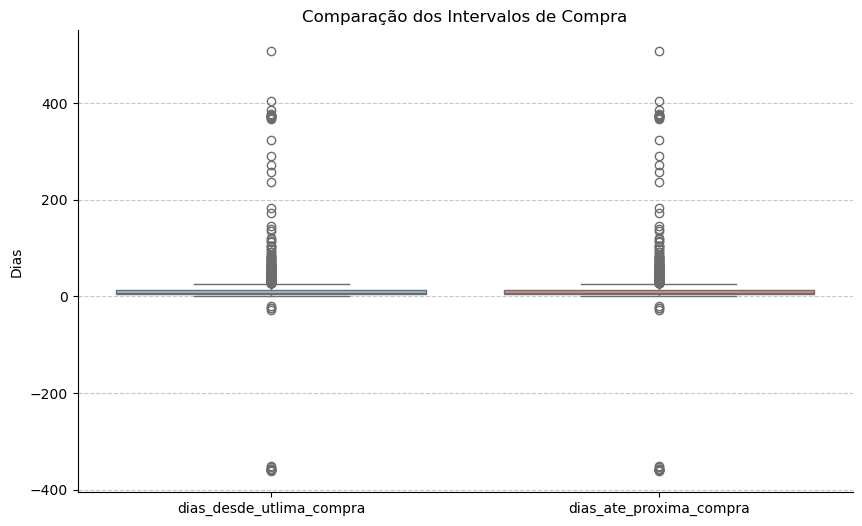

In [ ]:
# Box Plots das colunas "dias_desde_utlima_compra" e "dias_ate_proxima_compra"
# Definição das colunas a serem plotadas
colunas = df[['dias_desde_utlima_compra', 'dias_ate_proxima_compra']]

# Transformação dos dados para formato longo
df_long = colunas.melt(var_name='Variável', value_name='Dias')

# Criação da figura com tamanho adequado
plt.figure(figsize=(10, 6))

# Gráfico
sns.boxplot(data=df_long, x='Variável', y='Dias', palette=['skyblue', 'salmon'])

plt.title('Comparação dos Intervalos de Compra')
plt.xlabel('')
plt.ylabel('Dias')

# Grid pontilhado
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Remover bordas superior e direita
sns.despine()

plt.show()

A análise dos boxplots mostra que as variáveis **`dias_desde_ultima_compra`** e **`dias_ate_proxima_compra`** possuem distribuições semelhantes, com a maioria dos registros concentrada em intervalos curtos entre compras. Também foram identificados diversos valores extremos, principalmente acima de 100 dias e alguns valores negativos. Os valores elevados serão analisados para verificar se representam comportamentos reais dos clientes, enquanto os valores negativos serão investigados para identificar possíveis inconsistências nos cálculos ou na ordenação das datas, definindo posteriormente a necessidade de correção ou tratamento desses registros.

##### Análise dos valores negativos nas variáveis "dias_desde_utlima_compra" e "dias_ate_proxima_compra"

In [36]:
# Verificação da quantidade e porcentagem de registros com valores negativos
# Dias desde a última compra negativos
print(f'Quantidade de registros com dias desde a última compra negativos: {
    df[df['dias_desde_utlima_compra'] < 0].shape[0]}')
print(f'Porcentagem de registros com dias desde a última compra negativos: {
    (df['dias_desde_utlima_compra'] < 0).mean() * 100:.2f}%\n')

# Dias até a próxima compra negativos
print(f'Quantidade de registros com dias até a próxima compra negativos: {
    df[df['dias_ate_proxima_compra'] < 0].shape[0]}')
print(f'Porcentagem de registros com dias até a próxima compra negativos: {
    (df['dias_ate_proxima_compra'] < 0).mean() * 100:.2f}%')

Quantidade de registros com dias desde a última compra negativos: 15
Porcentagem de registros com dias desde a última compra negativos: 0.48%

Quantidade de registros com dias até a próxima compra negativos: 15
Porcentagem de registros com dias até a próxima compra negativos: 0.48%


Ao analisar as variáveis **`dias_desde_ultima_compra`** e **`dias_ate_proxima_compra`**, foi identificada a presença de valores negativos, o que inicialmente sugere possíveis inconsistências relacionadas ao cálculo dessas métricas ou à ordenação cronológica dos registros. No entanto, verificou-se que esses casos representam apenas **0,48% da base de dados**, indicando tratar-se de ocorrências pontuais e não de um problema generalizado.

Diante desse cenário, será realizada uma análise individual dos registros afetados, com o objetivo de validar a consistência das datas e a lógica empregada na construção das variáveis. Caso sejam identificados erros de processamento, ordenação ou cálculo, os registros serão corrigidos ou removidos conforme a natureza da inconsistência. Essa abordagem busca preservar a qualidade dos dados e minimizar possíveis impactos nas análises exploratórias e no desempenho dos modelos preditivos que serão desenvolvidos nas etapas seguintes.

In [ ]:
# Identificação dos clientes que estão gerando valores negativos na variável "dias_desde_utlima_compra"
df[df['dias_desde_utlima_compra'] < 0]

,data_pedido_entrega,semana,qnt_aguas_entregues,qnt_aguas_tickets,Obs,id_cliente,ano,mes,estacao,dias_desde_utlima_compra,intervalo_medio,frequencia_compra,media_aguas_cliente,total_pedidos,proxima_compra,dias_ate_proxima_compra,vai_comprar_15dias
1765,2024-05-13,Segunda,1,0,NaN,44,2024.0,5.0,Inverno,-362,4.18,139,1.00,139,2024-05-19,6,1
1766,2024-05-15,Quarta,1,0,NaN,89,2024.0,5.0,Inverno,-360,5.91,97,1.01,97,2024-05-21,6,1
1768,2024-05-16,Quinta,2,0,NaN,97,2024.0,5.0,Inverno,-359,10.30,66,2.05,66,2024-05-22,6,1
1773,2024-05-21,Quinta,2,0,NaN,50,2024.0,5.0,Inverno,-354,7.80,72,2.03,72,2024-06-07,17,0
1776,2024-05-17,Sexta,1,0,NaN,126,2024.0,5.0,Inverno,-359,21.71,24,1.00,24,2024-06-07,21,0
1778,2024-05-17,Sexta,1,0,NaN,7,2024.0,5.0,Inverno,-359,8.85,8,1.03,8,2024-05-23,6,1
1779,2024-05-17,Sexta,1,0,NaN,129,2024.0,5.0,Inverno,-359,4.33,118,1.06,118,2024-05-24,7,1
1780,2024-05-18,Sábado,1,0,NaN,25,2024.0,5.0,Inverno,-357,9.58,61,1.02,61,2024-05-25,7,1
1783,2024-05-18,Sábado,1,0,NaN,118,2024.0,5.0,Inverno,-357,10.34,53,1.01,53,2024-05-29,11,1
1784,2024-05-18,Sábado,1,0,NaN,132,2024.0,5.0,Inverno,-357,14.14,36,1.01,36,2024-06-04,17,0


In [41]:
# Identificação dos clientes que estão gerando valores negativos na variável "dias_ate_proxima_compra"
df[df['dias_ate_proxima_compra'] < 0]

,data_pedido_entrega,semana,qnt_aguas_entregues,qnt_aguas_tickets,Obs,id_cliente,ano,mes,estacao,dias_desde_utlima_compra,intervalo_medio,frequencia_compra,media_aguas_cliente,total_pedidos,proxima_compra,dias_ate_proxima_compra,vai_comprar_15dias
1751,2025-05-10,Sexta,1,0,NaN,89,2025.0,5.0,Inverno,371,5.91,96,1.01,96,2024-05-15,-360,1
1752,2025-05-10,Sexta,1,0,NaN,132,2025.0,5.0,Inverno,375,14.14,35,1.01,35,2024-05-18,-357,1
1753,2025-05-10,Sexta,2,0,NaN,97,2025.0,5.0,Inverno,369,10.30,65,2.05,65,2024-05-16,-359,1
1754,2025-05-10,Sexta,1,0,NaN,44,2025.0,5.0,Inverno,367,4.18,138,1.00,138,2024-05-13,-362,1
1755,2025-05-10,Sexta,2,0,NaN,50,2025.0,5.0,Inverno,373,7.80,71,2.03,71,2024-05-21,-354,1
1756,2025-05-10,Sexta,1,0,NaN,118,2025.0,5.0,Inverno,373,10.34,52,1.01,52,2024-05-18,-357,1
1757,2025-05-10,Sexta,1,0,NaN,25,2025.0,5.0,Inverno,375,9.58,60,1.02,60,2024-05-18,-357,1
1758,2025-05-11,Sábado,1,0,NaN,126,2025.0,5.0,Inverno,373,21.71,23,1.00,23,2024-05-17,-359,1
1759,2025-05-11,Sábado,1,0,NaN,7,2025.0,5.0,Inverno,370,8.85,7,1.03,7,2024-05-17,-359,1
1760,2025-05-11,Sábado,2,0,NaN,54,2025.0,5.0,Inverno,377,9.38,55,2.16,55,2024-05-24,-352,1


Foi possível identificar que os registros que apresentam valores negativos nas variáveis **`dias_desde_ultima_compra`** e **`dias_ate_proxima_compra`** pertencem aos mesmos clientes. Observa-se também que, quando uma dessas variáveis apresenta valores negativos, a outra geralmente contém valores coerentes para o mesmo registro.

Além disso, os valores negativos encontrados são muito semelhantes entre si, concentrando-se principalmente entre -350 e -370 dias, o que sugere a existência de um deslocamento aproximado de um ano entre as datas utilizadas no cálculo. Ao analisar os registros, verifica-se que algumas datas de compra de 2025 estão sendo relacionadas a compras ocorridas em 2024, gerando intervalos temporais negativos.

Dessa forma, há indícios de que o problema não está relacionado ao comportamento dos clientes, mas sim à lógica de cálculo das variáveis derivadas, possivelmente decorrente da ordenação cronológica dos registros ou da forma como foi aplicada a operação de deslocamento (shift) para identificar compras anteriores e futuras. Antes de qualquer tratamento, será realizada uma revisão da etapa de criação dessas variáveis para validar os cálculos e corrigir possíveis inconsistências na série temporal.

In [ ]:
# Verificação de ordenamento de um cliente especifico (89)
df[df['id_cliente'] == 89][[
    'data_pedido_entrega',
    'dias_desde_utlima_compra',
    'proxima_compra',
    'dias_ate_proxima_compra'
]].sort_values('data_pedido_entrega')

,data_pedido_entrega,dias_desde_utlima_compra,proxima_compra,dias_ate_proxima_compra
0,2023-01-02,0,2023-01-11,9
28,2023-01-11,9,2023-01-16,5
42,2023-01-16,5,2023-01-19,3
56,2023-01-19,3,2023-01-23,4
63,2023-01-23,4,2023-01-28,5
...,...,...,...,...
2727,2025-03-20,5,2025-03-28,8
2746,2025-03-28,8,2025-04-02,5
2767,2025-04-02,5,2025-04-08,6
2792,2025-04-08,6,NaT,0


In [ ]:
# Verificação de ordenação das datas do cliente 89
cliente_89 = df[df['id_cliente'] == 89]

cliente_89[['data_pedido_entrega']].sort_values('data_pedido_entrega')

,data_pedido_entrega
0,2023-01-02
28,2023-01-11
42,2023-01-16
56,2023-01-19
63,2023-01-23
...,...
2727,2025-03-20
2746,2025-03-28
2767,2025-04-02
2792,2025-04-08
